# Telecom Customer Churn Analysis

## Project Overview

Customer churn is a major challenge for telecom companies because losing customers can directly impact recurring revenue.

This project analyzes telecom customer data to understand churn patterns, customer behavior, and potential revenue loss associated with churned customers.

The analysis uses **Python for data cleaning and exploratory analysis** and **Power BI for interactive business reporting**.

## Objectives

- Analyze overall customer churn.
- Identify customer segments with higher churn rates.
- Understand factors associated with customer churn.
- Analyze the revenue impact of churn.
- Prepare a clean dataset for Power BI visualization.

## Business Questions

The analysis aims to answer the following questions:

1. What percentage of customers have churned?
2. Which customer groups have the highest churn rates?
3. How does churn vary with customer tenure?
4. Which contract and service types are associated with higher churn?
5. Does monthly charge influence churn?
6. Which payment methods have higher churn?
7. How much revenue is associated with churned customers?
8. Which customer characteristics are most strongly associated with churn?

## 1. Import Libraries

The following Python libraries are used for data loading, manipulation, analysis, and visualization.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

## 2. Load Dataset

The telecom customer dataset is loaded into a Pandas DataFrame for analysis.

In [2]:
data=pd.read_csv("D:/telecom_customer_churn.csv")
data.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


## 3. Data Understanding

Before performing any cleaning or analysis, the dataset structure, dimensions, data types, and basic statistics are examined.

In [15]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 7043
Number of columns: 39


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   str    
 12  Pho

In [16]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,7043,7043,0002-ORFBO,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,7043.0,NaN,NaN,NaN,46.509726,16.750352,19.0,32.0,46.0,60.0,80.0
Married,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Dependents,7043.0,NaN,NaN,NaN,0.468834,0.962807,0.0,0.0,0.0,0.0,9.0
City,7043,1106,Los Angeles,293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93486.070567,1856.767505,90001.0,92101.0,93518.0,95329.0,96150.0
Latitude,7043.0,NaN,NaN,NaN,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.756684,2.154425,-124.301372,-121.78809,-119.595293,-117.969795,-114.192901
Number of Referrals,7043.0,NaN,NaN,NaN,1.951867,3.001199,0.0,0.0,0.0,3.0,11.0


### Initial Data Observations

The dataset contains 7,043 customer records with demographic, service, contract, billing, revenue, and churn-related information.

Key observations from the initial statistical summary:

- Customer age ranges from 19 to 80 years.
- Customer tenure ranges from 1 to 72 months.
- Average monthly charge is approximately $63.60.
- Average total revenue per customer is approximately $3,034.38.
- The initial churn rate is approximately 26.54%.
- Several service-related variables contain missing values because they are not applicable to customers who do not use those services.
- The `Monthly Charge` field contains a negative minimum value and therefore requires further validation.

## 4. Data Quality Analysis

Data quality checks are performed to identify missing values, duplicate records, inconsistent values, and other potential data issues before analysis.

## Missing Value Analysis

Missing values were analyzed to determine whether they represented data quality issues or valid business scenarios.

Examples include:
- Customers without internet service.
- Customers without phone service.
- Customers who did not churn.

In [17]:
missing_values = data.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

Churn Reason                         5174
Churn Category                       5174
Device Protection Plan               1526
Streaming TV                         1526
Online Backup                        1526
Online Security                      1526
Avg Monthly GB Download              1526
Streaming Music                      1526
Streaming Movies                     1526
Internet Type                        1526
Unlimited Data                       1526
Premium Tech Support                 1526
Multiple Lines                        682
Avg Monthly Long Distance Charges     682
dtype: int64

In [ ]:
missing_percentage = ( data.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({"Missing Count": data.isnull().sum(),"Missing Percentage": missing_percentage})

missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing Percentage
Avg Monthly GB Download,1526,21.666903
Avg Monthly Long Distance Charges,682,9.683374
Churn Category,5174,73.463013
Churn Reason,5174,73.463013
Device Protection Plan,1526,21.666903
Internet Type,1526,21.666903
Multiple Lines,682,9.683374
Online Backup,1526,21.666903
Online Security,1526,21.666903
Premium Tech Support,1526,21.666903


### Missing Value Findings

The missing-value analysis shows that most missing values are associated with service-dependent fields.

- `Avg Monthly GB Download` and internet-related service fields have 1,526 missing records, representing customers without internet service.
- `Avg Monthly Long Distance Charges` and `Multiple Lines` have 682 missing records, corresponding to customers without phone service.
- `Churn Category` and `Churn Reason` have 5,174 missing records because these fields apply only to customers who churned.
- The missing values therefore represent valid business scenarios rather than data quality errors in most cases.

In [52]:
data[data["Internet Service"]=="No"].shape

(1526, 41)

In [53]:
data[data["Phone Service"] == "No"].shape

(682, 41)

In [21]:
print("Customers without Internet Service:",
            (data["Internet Service"] == "No").sum())

print("Customers without Phone Service:",
      (data["Phone Service"] == "No").sum())

print("Customers who stayed:",
      (data["Customer Status"] == "Stayed").sum())


Customers without Internet Service: 1526
Customers without Phone Service: 682
Customers who stayed: 4720


### Validation Result

The missing-value patterns are consistent with the business structure of the dataset.

- The 1,526 missing internet-related records correspond exactly to customers without internet service.
- The 682 missing phone-related records correspond exactly to customers without phone service.
- The 5,174 missing churn-category and churn-reason records correspond to customers who did not churn.

Therefore, these missing values are treated as **structural missing values** rather than data quality errors.

In [54]:
data["Offer"] = data["Offer"].fillna("No Offer")

In [55]:
data["Offer"].isnull().sum()

np.int64(0)

### Duplicate Record Check

Duplicate records are checked to ensure that each customer is represented appropriately in the dataset.

In [22]:
duplicate_count = data.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


### Duplicate Check Result

The dataset contains **0 duplicate records**. Therefore, no duplicate rows were removed during the cleaning process.

### Numerical Data Validation

Numerical variables are checked for unexpected or logically invalid values before performing further analysis.

In [ ]:
# Check for negative monthly charges

negative_monthly_charge = data[data["Monthly Charge"] < 0]
[
    ["Customer ID", "Monthly Charge",
     "Total Charges", "Total Revenue", "Customer Status"]
]

negative_monthly_charge

,Customer ID,Monthly Charge,Total Charges,Total Revenue,Customer Status
1,0003-MKNFE,-4.0,542.40,610.28,Stayed
32,0052-DCKON,-2.0,7942.15,10830.97,Stayed
170,0274-JKUJR,-3.0,465.70,465.70,Stayed
232,0361-HJRDX,-8.0,4539.60,4669.60,Stayed
336,0495-ZBNGW,-1.0,343.95,397.25,Churned
...,...,...,...,...,...
6894,9793-WECQC,-1.0,2192.90,3301.73,Stayed
6918,9821-BESNZ,-7.0,6860.60,8995.92,Stayed
6976,9898-KZQDZ,-1.0,3640.45,5620.45,Churned
7020,9961-JBNMK,-1.0,2030.30,2907.77,Churned


### Negative Monthly Charge Findings

The validation identified **120 customers with negative monthly charges**.

Since a monthly telecom charge should not normally be negative, these records require treatment before further analysis.

The negative values range from **-1 to -10**, while the associated `Total Charges` and `Total Revenue` values remain positive.

For this project, the negative monthly charges will be treated as invalid values and replaced with missing values before analysis.

In [24]:
data.loc[data["Monthly Charge"] < 0, "Monthly Charge"] = np.nan

print("Invalid Monthly Charge values remaining:",
    (data["Monthly Charge"] < 0).sum())

Invalid Monthly Charge values remaining: 0


### Validation Result

All negative `Monthly Charge` values have been removed from the valid numerical range by converting them to missing values.

These records will not be assigned an artificial charge because the correct charge cannot be determined from the available data.

In [56]:
(data["Monthly Charge"] < 0).sum()

np.int64(0)

## 6. Feature Engineering

Additional analytical features are created to make customer churn patterns easier to measure and visualize.

### Churn Flag

A binary `Churn Flag` is created from `Customer Status`:

- `1` = Churned
- `0` = Stayed

This variable allows churn rates to be calculated numerically.

In [25]:
data["Churn Flag"] = (data["Customer Status"] == "Churned").astype(int)

data[["Customer Status", "Churn Flag"]].head()

,Customer Status,Churn Flag
0,Stayed,0
1,Stayed,0
2,Churned,1
3,Churned,1
4,Churned,1


### Churn Flag Validation

The distribution of the newly created flag is checked to ensure that it correctly represents customer status.

In [26]:
data["Churn Flag"].value_counts()

Churn Flag
0    5174
1    1869
Name: count, dtype: int64

### Tenure Group

Customers are grouped by their tenure in months to analyze whether customer retention varies between newer and longer-term customers.

In [27]:
data["Tenure Group"] = pd.cut(data["Tenure in Months"],
    bins=[0, 6, 12, 24, 48, np.inf],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49+ Months"])

data["Tenure Group"].value_counts().sort_index()

Tenure Group
0-6 Months      1470
7-12 Months      716
13-24 Months    1024
25-48 Months    1594
49+ Months      2239
Name: count, dtype: int64

In [28]:
data[[
    "Customer ID",
    "Tenure in Months",
    "Tenure Group",
    "Customer Status",
    "Churn Flag"
]].head(10)

,Customer ID,Tenure in Months,Tenure Group,Customer Status,Churn Flag
0,0002-ORFBO,9,7-12 Months,Stayed,0
1,0003-MKNFE,9,7-12 Months,Stayed,0
2,0004-TLHLJ,4,0-6 Months,Churned,1
3,0011-IGKFF,13,13-24 Months,Churned,1
4,0013-EXCHZ,3,0-6 Months,Churned,1
5,0013-MHZWF,9,7-12 Months,Stayed,0
6,0013-SMEOE,71,49+ Months,Stayed,0
7,0014-BMAQU,63,49+ Months,Stayed,0
8,0015-UOCOJ,7,7-12 Months,Stayed,0
9,0016-QLJIS,65,49+ Months,Stayed,0


## 7. Exploratory Data Analysis

### Overall Customer Churn

The overall churn rate is calculated to understand the proportion of customers who have left the telecom service.

In [29]:
churn_rate = data["Churn Flag"].mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


### Churn Distribution

The distribution of customers who stayed and churned is visualized to provide an overview of customer retention.

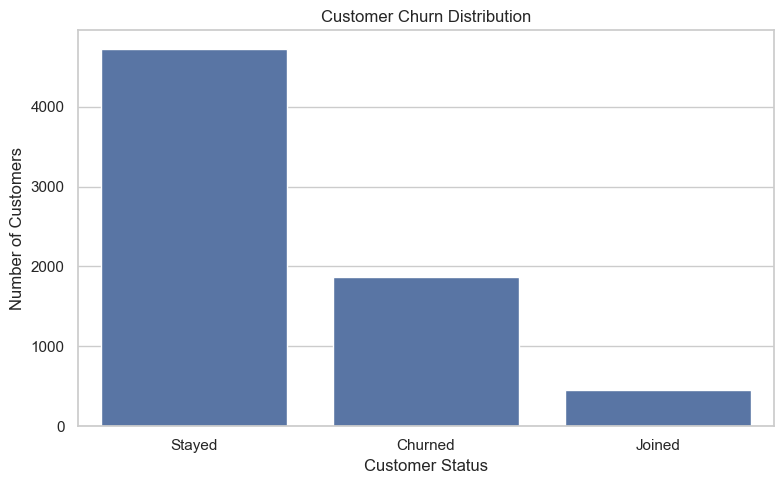

In [30]:
churn_counts = data["Customer Status"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(x=churn_counts.index,
            y=churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Key Insight

Approximately **26.5% of customers have churned**, while the majority of customers have either stayed with the company or recently joined.

This indicates that customer retention is an important area for further analysis.

### Churn Rate by Tenure Group

Customer tenure is analyzed to determine whether churn behavior differs between newer and longer-term customers.

In [31]:
tenure_churn = (data.groupby("Tenure Group", observed=True)["Churn Flag"]
                .mean().mul(100).reset_index())
tenure_churn

,Tenure Group,Churn Flag
0,0-6 Months,53.333333
1,7-12 Months,35.335196
2,13-24 Months,28.710938
3,25-48 Months,20.388959
4,49+ Months,9.513176


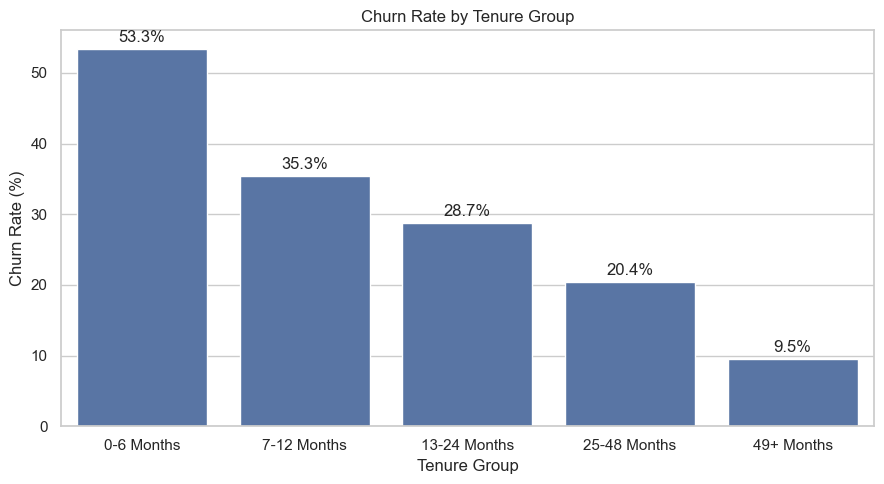

In [33]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(data=tenure_churn,
                 x="Tenure Group",
                 y="Churn Flag")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3)

plt.tight_layout()
plt.show()

### Key Insight

Churn is highest among newer customers and decreases consistently as customer tenure increases.

- 0–6 months: **53.3%**
- 7–12 months: **35.3%**
- 13–24 months: **28.7%**
- 25–48 months: **20.4%**
- 49+ months: **9.5%**

This indicates that **newer customers are significantly more likely to churn**, while long-term customers show much stronger retention.

### Churn Rate by Contract Type

Contract type is analyzed to determine whether customers with different contract commitments have different churn rates.

In [35]:
contract_churn = (data.groupby("Contract")["Churn Flag"]
                    .mean().mul(100).sort_values(ascending=False).reset_index())

contract_churn

,Contract,Churn Flag
0,Month-to-Month,45.844875
1,One Year,10.709677
2,Two Year,2.549124


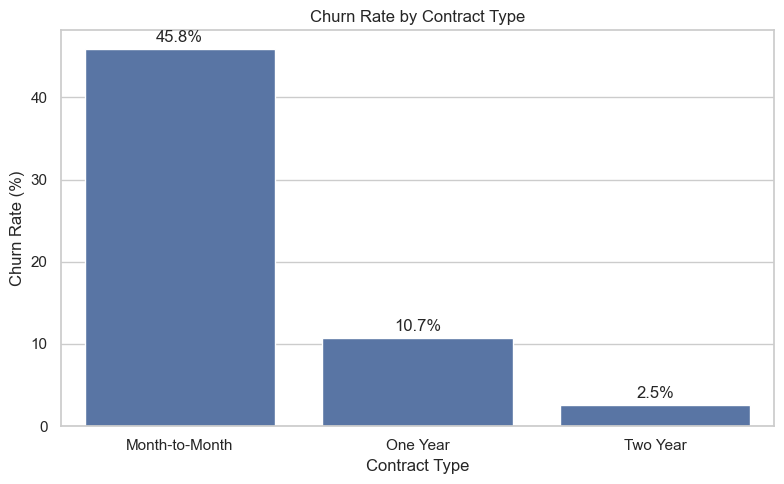

In [36]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=contract_churn,
                x="Contract",
                y="Churn Flag")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3)

plt.tight_layout()
plt.show()

### Key Insight

Churn is strongly concentrated among month-to-month customers.

- Month-to-Month: **45.8%**
- One Year: **10.7%**
- Two Year: **2.5%**

Customers with longer-term contracts have substantially lower churn rates than month-to-month customers, indicating that contract commitment is strongly associated with customer retention.

### Churn Rate by Payment Method

Payment methods are analyzed to identify differences in customer churn behavior and determine whether certain payment methods are associated with higher churn.

In [37]:
payment_churn = (data.groupby("Payment Method")["Churn Flag"]
                .mean().mul(100).sort_values(ascending=False).reset_index())
payment_churn

,Payment Method,Churn Flag
0,Mailed Check,36.883117
1,Bank Withdrawal,33.998465
2,Credit Card,14.477992


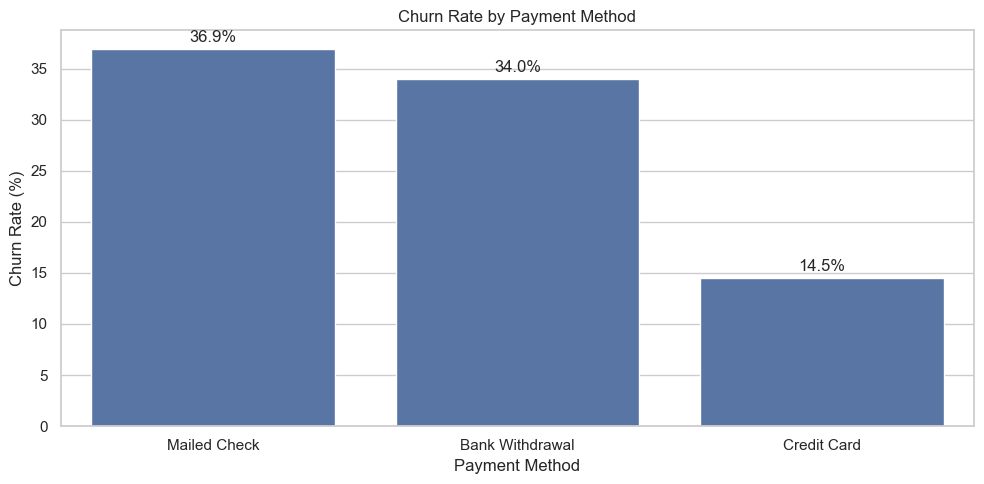

In [38]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(data=payment_churn,
                 x="Payment Method",
                 y="Churn Flag")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3)

plt.tight_layout()
plt.show()

### Key Insight

Churn is highest among customers using mailed checks and bank withdrawal.

- Mailed Check: **36.9%**
- Bank Withdrawal: **34.0%**
- Credit Card: **14.5%**

Customers using mailed checks and bank withdrawal show substantially higher churn rates than credit card users.

### Churn Rate by Internet Service

Internet service type is analyzed to determine whether customer churn differs between customers with and without internet service.

In [39]:
internet_churn = (data.groupby("Internet Service")["Churn Flag"]
                  .mean().mul(100).reset_index())

internet_churn

,Internet Service,Churn Flag
0,No,7.404980
1,Yes,31.828893


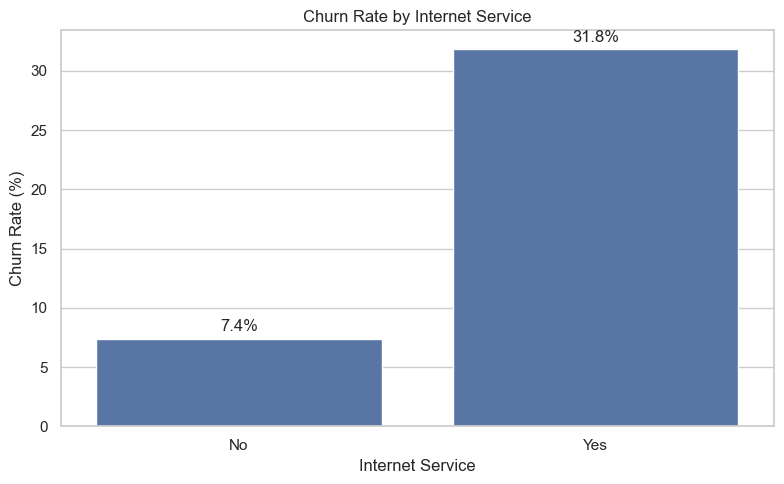

In [40]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=internet_churn,
                 x="Internet Service",
                 y="Churn Flag")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3)

plt.tight_layout()
plt.show()

### Key Insight

Customers with internet service have a substantially higher churn rate than customers without internet service.

- Internet Service: **31.8%**
- No Internet Service: **7.4%**

This indicates that internet-service customers represent a higher-churn segment and should be examined further by internet connection type and subscribed services.

### Churn Rate by Internet Type

Internet connection type is analyzed among customers with internet service to identify differences in churn behavior across connection types.

In [41]:
internet_type_churn = (data.dropna(subset=["Internet Type"])
                        .groupby("Internet Type")["Churn Flag"].mean().mul(100)
                        .sort_values(ascending=False).reset_index())

internet_type_churn

,Internet Type,Churn Flag
0,Fiber Optic,40.724876
1,Cable,25.662651
2,DSL,18.583535


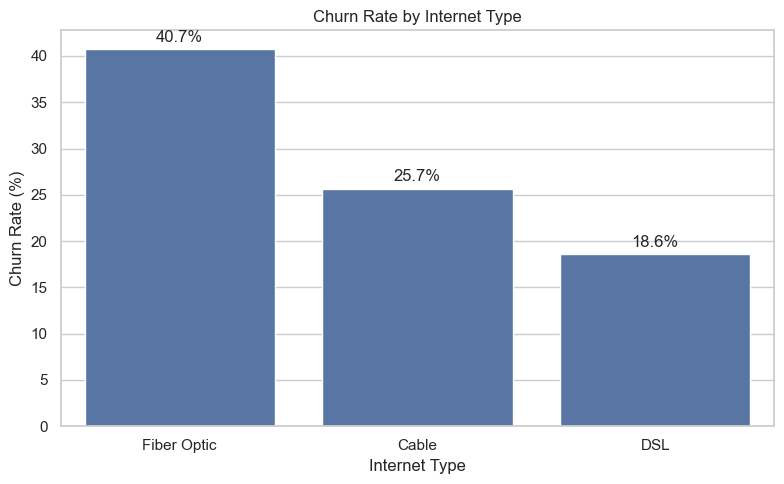

In [42]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=internet_type_churn,
                 x="Internet Type",
                 y="Churn Flag")

plt.title("Churn Rate by Internet Type")
plt.xlabel("Internet Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3)

plt.tight_layout()
plt.show()

### Key Insight

Fiber Optic customers have the highest churn rate, followed by Cable and DSL customers.

- Fiber Optic: **40.7%**
- Cable: **25.7%**
- DSL: **18.6%**

The significantly higher churn among Fiber Optic customers makes internet connection type an important area for further churn analysis.

### Monthly Charges and Churn

Monthly charges are compared between churned and retained customers to determine whether customer pricing is associated with churn behavior.

In [43]:
monthly_charge_summary = (data.groupby("Customer Status")["Monthly Charge"]
                          .agg(["count", "mean", "median"]).round(2))

monthly_charge_summary

,count,mean,median
Customer Status,,,
Churned,1839,74.62,79.65
Joined,448,43.41,44.00
Stayed,4636,62.96,66.40


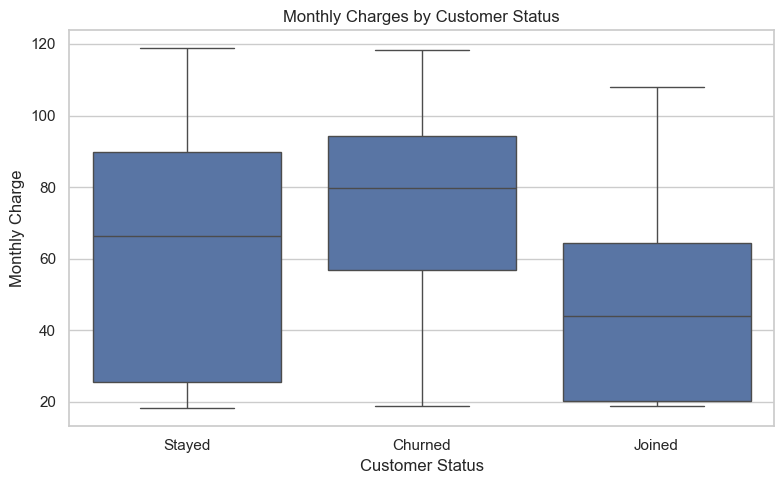

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=data,
             x="Customer Status",
             y="Monthly Charge")

plt.title("Monthly Charges by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charge")

plt.tight_layout()
plt.show()

### Key Insight

Monthly charge distributions are compared between churned and retained customers to identify whether pricing levels are associated with customer churn.

### Churn Rate by Age Group

Customers are grouped by age to examine whether churn behavior differs across different age segments.

In [45]:
data["Age Group"] = pd.cut(data["Age"],
                    bins=[18, 30, 45, 60, 80],
                    labels=["19-30", "31-45", "46-60", "61-80"])

age_churn = (data.groupby("Age Group", observed=True)["Churn Flag"]
            .mean().mul(100).reset_index())

age_churn

,Age Group,Churn Flag
0,19-30,22.367560
1,31-45,23.520329
2,46-60,24.305919
3,61-80,36.462094


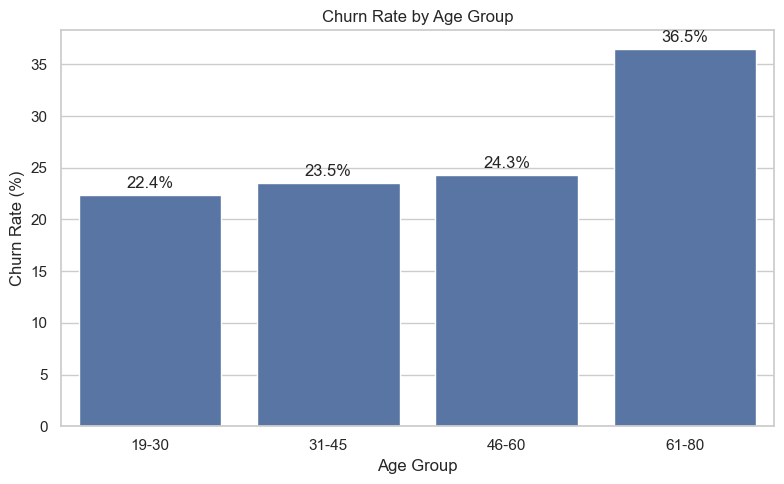

In [46]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=age_churn,
                x="Age Group",
                y="Churn Flag")

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3)

plt.tight_layout()
plt.show()

### Key Insight

Churn increases across the older age segments, with the highest rate among customers aged 61–80.

- 19–30: **22.4%**
- 31–45: **23.5%**
- 46–60: **24.3%**
- 61–80: **36.5%**

Customers aged 61–80 have the highest churn rate at **36.5%**, making this an important demographic segment for further analysis.

### Churn by Category

Churn categories are analyzed to understand the major areas associated with customer attrition.

In [47]:
churn_category = (data.loc[data["Churn Flag"] == 1, "Churn Category"].value_counts())

churn_category

Churn Category
Competitor         841
Dissatisfaction    321
Attitude           314
Price              211
Other              182
Name: count, dtype: int64

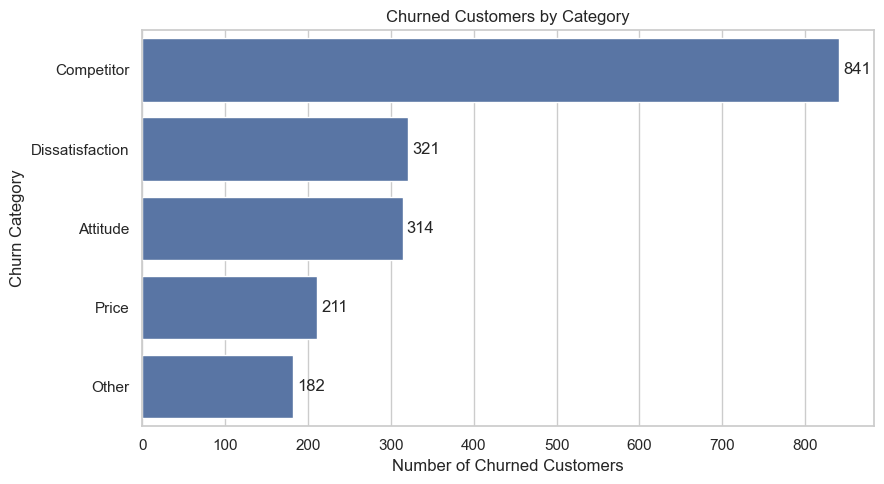

In [48]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=churn_category.values,
    y=churn_category.index)

plt.title("Churned Customers by Category")
plt.xlabel("Number of Churned Customers")
plt.ylabel("Churn Category")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### Key Insight

Competitor-related factors are the largest churn category, accounting for **841 churned customers**.

Dissatisfaction and attitude-related factors follow with **321** and **314** customers respectively, while price-related churn accounts for **211** customers.

## 8. Revenue Impact Analysis

### Revenue Associated with Churned Customers

The revenue associated with churned customers is analyzed to understand the financial impact of customer attrition.

In [49]:
total_revenue = data["Total Revenue"].sum()

churned_revenue = data.loc[
    data["Churn Flag"] == 1,
    "Total Revenue"].sum()

churned_revenue_percentage = (churned_revenue / total_revenue) * 100

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Revenue from Churned Customers: ${churned_revenue:,.2f}")
print(f"Churned Revenue Share: {churned_revenue_percentage:.2f}%")

Total Revenue: $21,371,131.69
Revenue from Churned Customers: $3,684,459.82
Churned Revenue Share: 17.24%


### Key Insight

Churned customers generated **$3.68M**, representing **17.24% of total customer revenue**.

This shows that customer churn has a meaningful financial impact in addition to customer loss.

### Top 10 Churn Reasons

The most common reasons reported by churned customers are analyzed to identify the primary factors contributing to customer attrition.

In [50]:
churn_reasons = (data.loc[data["Churn Flag"] == 1, "Churn Reason"].value_counts().head(10))

churn_reasons

Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Name: count, dtype: int64

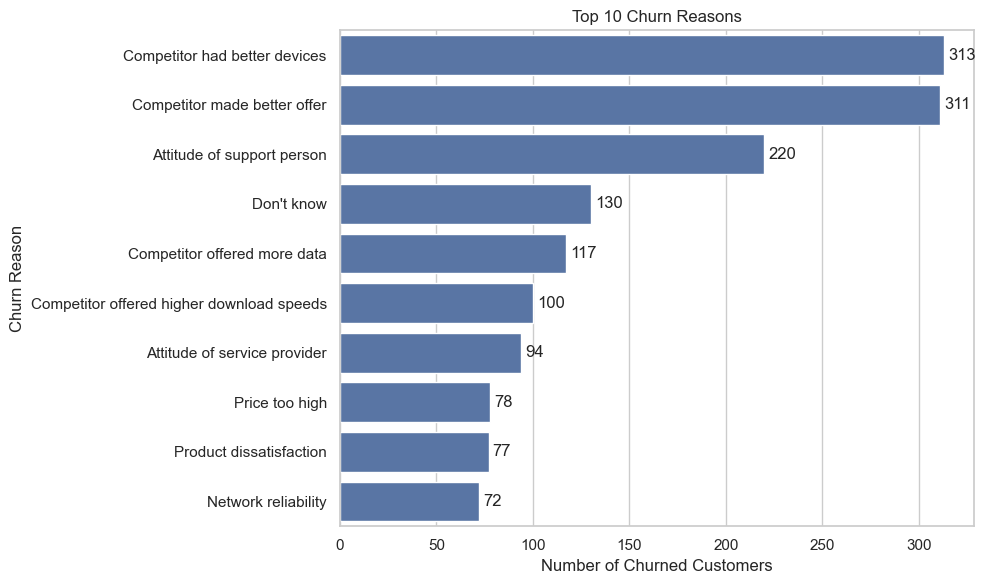

In [51]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=churn_reasons.values,
    y=churn_reasons.index)

plt.title("Top 10 Churn Reasons")
plt.xlabel("Number of Churned Customers")
plt.ylabel("Churn Reason")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### Key Insight

The leading churn reasons are related to **competitor offerings and service experience**.

- Competitor had better devices: **313**
- Better offer: **311**
- Attitude of support: **220**
- Don't know: **130**
- Competitor offered more data: **117**
- Competitor offered higher download speed: **100**
- Attitude of service provider: **94**
- Price too high: **78**
- Product dissatisfaction: **77**
- Network reliability: **72**

Competitor-related reasons are the most prominent drivers of customer churn, while support and service experience are also significant contributors.

### Key Insight

Competitor offerings are the leading reported reasons for churn, particularly better devices and better offers. Support attitude and service experience are also notable contributors.

## 9. Final Key Findings

The analysis identified several important patterns in customer churn, covering customer tenure, contracts, payment methods, internet services, demographics, and revenue impact.

### Key Findings

- Overall customer churn is approximately **26.5%**.
- Customers with **0–6 months tenure** have the highest churn rate at **53.3%**.
- **Month-to-month contracts** have a significantly higher churn rate (**45.8%**) than longer-term contracts.
- **Fiber Optic customers** have the highest churn rate among internet types at **40.7%**.
- Customers aged **61–80** have the highest age-group churn rate at **36.5%**.
- **Mailed Check** customers have the highest churn rate among payment methods at **36.9%**.
- **Competitor-related factors** are the largest churn category.
- Churned customers account for **$3.68M**, representing **17.24% of total revenue**.


## Data Cleaning Summary

Key actions performed:

- Verified data types.
- Checked for duplicate records.
- Validated missing values using business logic.
- Filled missing values in the Offer column with "No Offer".
- Created a Churn Flag variable for reporting.
- Exported a cleaned dataset for Power BI dashboard development.

## 10. Export Cleaned Dataset

The cleaned and feature-engineered dataset is exported for use in Power BI.

The final dataset includes the original customer attributes along with the analytical features created during the analysis.

In [57]:
output_path = "D:/cleaned_telecom_customer_churn.csv"

data.to_csv(
    output_path,
    index=False
)

print(f"Cleaned dataset exported to: {output_path}")

Cleaned dataset exported to: D:/cleaned_telecom_customer_churn.csv


In [58]:
print("Final dataset shape:", data.shape)
print("Final number of columns:", len(data.columns))

Final dataset shape: (7043, 41)
Final number of columns: 41


### Final Dataset Validation

The final dataset contains **7,043 customer records and 41 columns** after data cleaning and feature engineering.

The dataset is ready to be imported into Power BI for interactive dashboard development.

## 11. Conclusion

This analysis identified the major patterns associated with telecom customer churn.

Customer tenure and contract type show particularly strong differences in churn rates, with newer and month-to-month customers experiencing substantially higher churn. Internet type, payment method, and age also show noticeable differences in churn behavior.

Competitor-related factors are the leading reported churn category, while churned customers account for 17.24% of total customer revenue.

The cleaned dataset and engineered features are now ready for interactive visualization and further analysis in Power BI.